In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

In [27]:
# Get the images and labels
train_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_imgs.npy')
train_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_labels.npy')
train_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_metadata.npy')
train_header = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_2h.npy')
val_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_imgs.npy')
val_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_labels.npy')
val_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_metadata.npy')
val_header = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_2h.npy')
test_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_imgs.npy')
test_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_labels.npy')
test_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_metadata.npy')
test_header = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_2h.npy')

In [28]:
# Examine class label imbalance
neg, pos = np.bincount(train_labels.astype(int))
total = neg + pos
print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
    total, pos, 100 * pos / total))

Examples:
    Total: 10290
    Positive: 5145 (50.00% of total)



In [29]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [30]:
# Load in the images
def load_image(path, meta, label, header):
    def read_npz(p, m):
        p = p.decode() # From byte to string
        img = np.load(p)['data']

        window_min = m[0]
        window_max = m[1]
        img = np.clip(img, window_min, window_max)
        img = (img - window_min) / (window_max - window_min) * 255.0
        return img.astype(np.float32)
    
    img = tf.numpy_function(read_npz, [path, meta], tf.float32)
    img = tf.expand_dims(img, axis=-1)
    img.set_shape([1024, 1024, 1])
    
    return {'image_input': img, 'header_input': header}, label

In [31]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_meta, train_labels, train_header))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_meta, val_labels, val_header))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_meta, test_labels, test_header))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32)

In [32]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [33]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(1024, 1024, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [34]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 1030,      │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 1030, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 512, 512,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 512, 512,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 512, 512,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 514, 514,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 256, 256,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 256, 256,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 256, 256,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 256, 256,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 256, 256,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 256, 256,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 256, 256,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 256, 256,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 256, 256,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 256, 256,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 256, 256,  │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [35]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(1024, 1024, 1), name = 'image_input')
x = data_augmentation(image_input)
x = tf.keras.layers.Concatenate()([x, x, x])
x = preprocess_input(x) 

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)

# Headers branch
header_input = tf.keras.Input(shape=(2,), name = 'header_input')
h = layers.Dense(32, activation="relu")(header_input)

combined = layers.concatenate([x, h])
combined = layers.Dense(64, activation="relu")(combined)
outputs = layers.Dense(1, activation="sigmoid")(combined)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs = [image_input, header_input], outputs = outputs) # wrap all layers

In [36]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 1024,      │          0 │ image_input[0][0] │
│ (Sequential)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 1024,      │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 1024, 3)          │            │ sequential_1[0][… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1024,      │          0 │ concatenate_2[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 1024,      │          0 │ concatenate_2[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 1024,      │          0 │ concatenate_2[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 1024,      │          0 │ get_item_3[0][0], │
│                     │ 1024, 3)          │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024,      │          0 │ stack_1[0][0]     │
│                     │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 32, 32,    │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ header_input        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │         96 │ header_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 2080)      │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │    133,184 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,721,057 (90.49 MB)

 Trainable params: 133,345 (520.88 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name = 'auc'),
    ]
)

In [38]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [39]:
initial_epochs = 20
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 129s 385ms/step - auc: 0.5879 - loss: 0.7214 - val_auc: 0.6712 - val_loss: 0.6538
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 160s 441ms/step - auc: 0.6449 - loss: 0.6616 - val_auc: 0.6890 - val_loss: 0.6309
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 202s 441ms/step - auc: 0.6711 - loss: 0.6435 - val_auc: 0.7027 - val_loss: 0.6341
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 142s 441ms/step - auc: 0.6791 - loss: 0.6377 - val_auc: 0.7076 - val_loss: 0.6185
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 183s 381ms/step - auc: 0.6854 - loss: 0.6325 - val_auc: 0.7102 - val_loss: 0.6293
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 123s 380ms/step - auc: 0.6969 - loss: 0.6250 - val_auc: 0.7154 - val_loss: 0.6167
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 123s 380ms/step - auc: 0.6975 - loss: 0.6243 - val_auc: 0.7210 - val_loss: 0.6104
Epoch 8/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 141s 378ms/step - auc: 0.7054 - loss: 0.6195 - val_auc: 0.7200 - val_loss: 0.6313
Epoch 9/20
322/322 ━━━━━

In [40]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [41]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [42]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 1024,      │          0 │ image_input[0][0] │
│ (Sequential)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 1024,      │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 1024, 3)          │            │ sequential_1[0][… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1024,      │          0 │ concatenate_2[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 1024,      │          0 │ concatenate_2[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 1024,      │          0 │ concatenate_2[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 1024,      │          0 │ get_item_3[0][0], │
│                     │ 1024, 3)          │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024,      │          0 │ stack_1[0][0]     │
│                     │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 32, 32,    │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ header_input        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │         96 │ header_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 2080)      │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │    133,184 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,987,749 (91.51 MB)

 Trainable params: 17,083,873 (65.17 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

 Optimizer params: 266,692 (1.02 MB)

In [43]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name = 'auc'),
    ],
)

In [44]:
# Train the model
fine_tune_epochs = 20
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds,
                         callbacks=callbacks)

Epoch 21/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 180s 533ms/step - auc: 0.7219 - loss: 0.6111 - val_auc: 0.7594 - val_loss: 0.5795
Epoch 22/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 220s 589ms/step - auc: 0.7709 - loss: 0.5636 - val_auc: 0.7771 - val_loss: 0.5723
Epoch 23/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 183s 529ms/step - auc: 0.7916 - loss: 0.5409 - val_auc: 0.7847 - val_loss: 0.5910
Epoch 24/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 202s 528ms/step - auc: 0.8040 - loss: 0.5294 - val_auc: 0.7886 - val_loss: 0.5954
Epoch 25/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 202s 529ms/step - auc: 0.8200 - loss: 0.5086 - val_auc: 0.7990 - val_loss: 0.5441
Epoch 26/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 201s 525ms/step - auc: 0.8279 - loss: 0.4983 - val_auc: 0.7981 - val_loss: 0.5421
Epoch 27/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 171s 530ms/step - auc: 0.8362 - loss: 0.4888 - val_auc: 0.7997 - val_loss: 0.5462
Epoch 28/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 221s 589ms/step - auc: 0.8434 - loss: 0.4815 - val_auc: 0.8048 - val_loss: 0.5496
Epoch 29/40
322/

In [45]:
# Evaluate model
model.evaluate(test_ds)

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 309ms/step - auc: 0.8203 - loss: 0.5198


[0.5198454260826111, 0.8203237652778625]

In [46]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

69/69 ━━━━━━━━━━━━━━━━━━━━ 25s 331ms/step


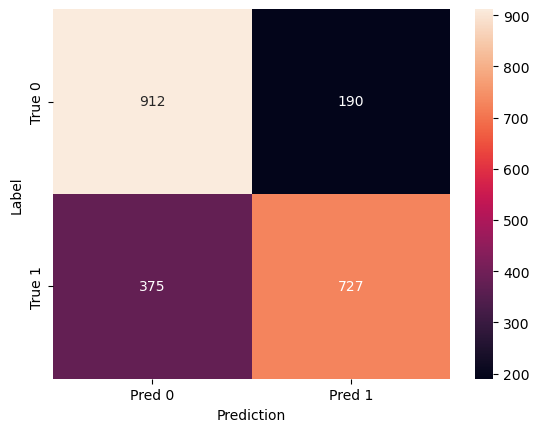

In [47]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

In [48]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7202


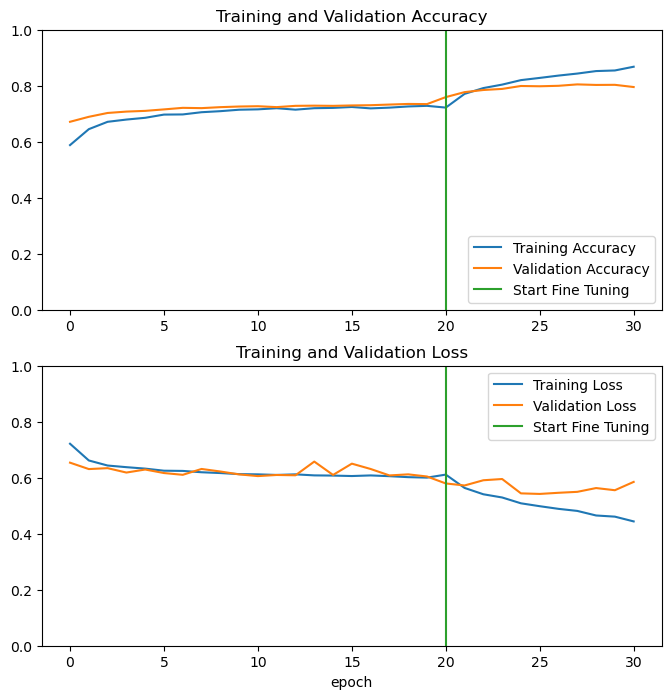

In [49]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc']
val_acc = history.history['val_auc'] + history_fine.history['val_auc']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [50]:
print(history.history.keys())
print(history_fine.history.keys())

dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])
dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])
